## Redes Neuronales Convolucionales con PyTorch

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import sampler
import torchvision.datasets as datasets
import torchvision.transforms as T
import matplotlib.pyplot as plt

In [ ]:
def plot_history(history, figsize=(12, 4), title_suffix=''):
    required_keys = ['train_loss', 'val_loss', 'train_acc', 'val_acc']
    for key in required_keys:
        if key not in history:
            raise KeyError(f"Falta la llave '{key}' en history")

    epochs_range = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=figsize)

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='train_loss')
    plt.plot(epochs_range, history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f"Loss por época {title_suffix}".strip())
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_acc'], label='train_acc')
    plt.plot(epochs_range, history['val_acc'], label='val_acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f"Accuracy por época {title_suffix}".strip())
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### Descargar Cifar10 dataset

In [ ]:
DATA_PATH = '../data/Databases/cifar-10-batches-py'
NUM_TRAIN = 50000
NUM_VAL = 5000
NUM_TEST = 5000
MINIBATCH_SIZE = 64

transform_cifar = T.Compose([
                T.ToTensor(),
                T.Normalize([0.491, 0.482, 0.447], [0.247, 0.243, 0.261])
            ])

# Train dataset
cifar10_train = datasets.CIFAR10(DATA_PATH, train=True, download=True,
                             transform=transform_cifar)
train_loader = DataLoader(cifar10_train, batch_size=MINIBATCH_SIZE, 
                          sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN)))
#Validation set
cifar10_val = datasets.CIFAR10(DATA_PATH, train=False, download=True,
                           transform=transform_cifar)
val_loader = DataLoader(cifar10_val, batch_size=MINIBATCH_SIZE, 
                        sampler=sampler.SubsetRandomSampler(range(NUM_VAL)))
#Test set
cifar10_test = datasets.CIFAR10(DATA_PATH, train=False, download=True, 
                            transform=transform_cifar)
test_loader = DataLoader(cifar10_test, batch_size=MINIBATCH_SIZE,
                        sampler=sampler.SubsetRandomSampler(range(NUM_VAL, NUM_VAL + NUM_TEST)))

c:\Users\jose.rodriguezb\Desktop\Proyecto-I-Clasificador-Imagenes\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [ ]:
cifar10_train

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ../data/Databases/cifar-10-batches-py
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.491, 0.482, 0.447], std=[0.247, 0.243, 0.261])
           )

### Usar GPUs

In [ ]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(device)

cuda


### Mostrar imágenes

La imagen muestreada representa un: airplane


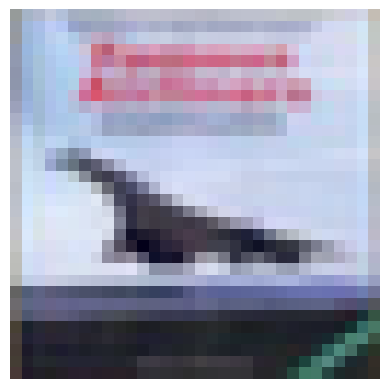

In [ ]:
classes = test_loader.dataset.classes
def plot_figure(image):
    plt.imshow(np.transpose(image,(1,2,0)))
    plt.axis('off')
    plt.show()

rnd_sample_idx = np.random.randint(len(test_loader))
print(f'La imagen muestreada representa un: {classes[test_loader.dataset[rnd_sample_idx][1]]}')
image = test_loader.dataset[rnd_sample_idx][0]
image = (image - image.min()) / (image.max() -image.min() )
plot_figure(image)


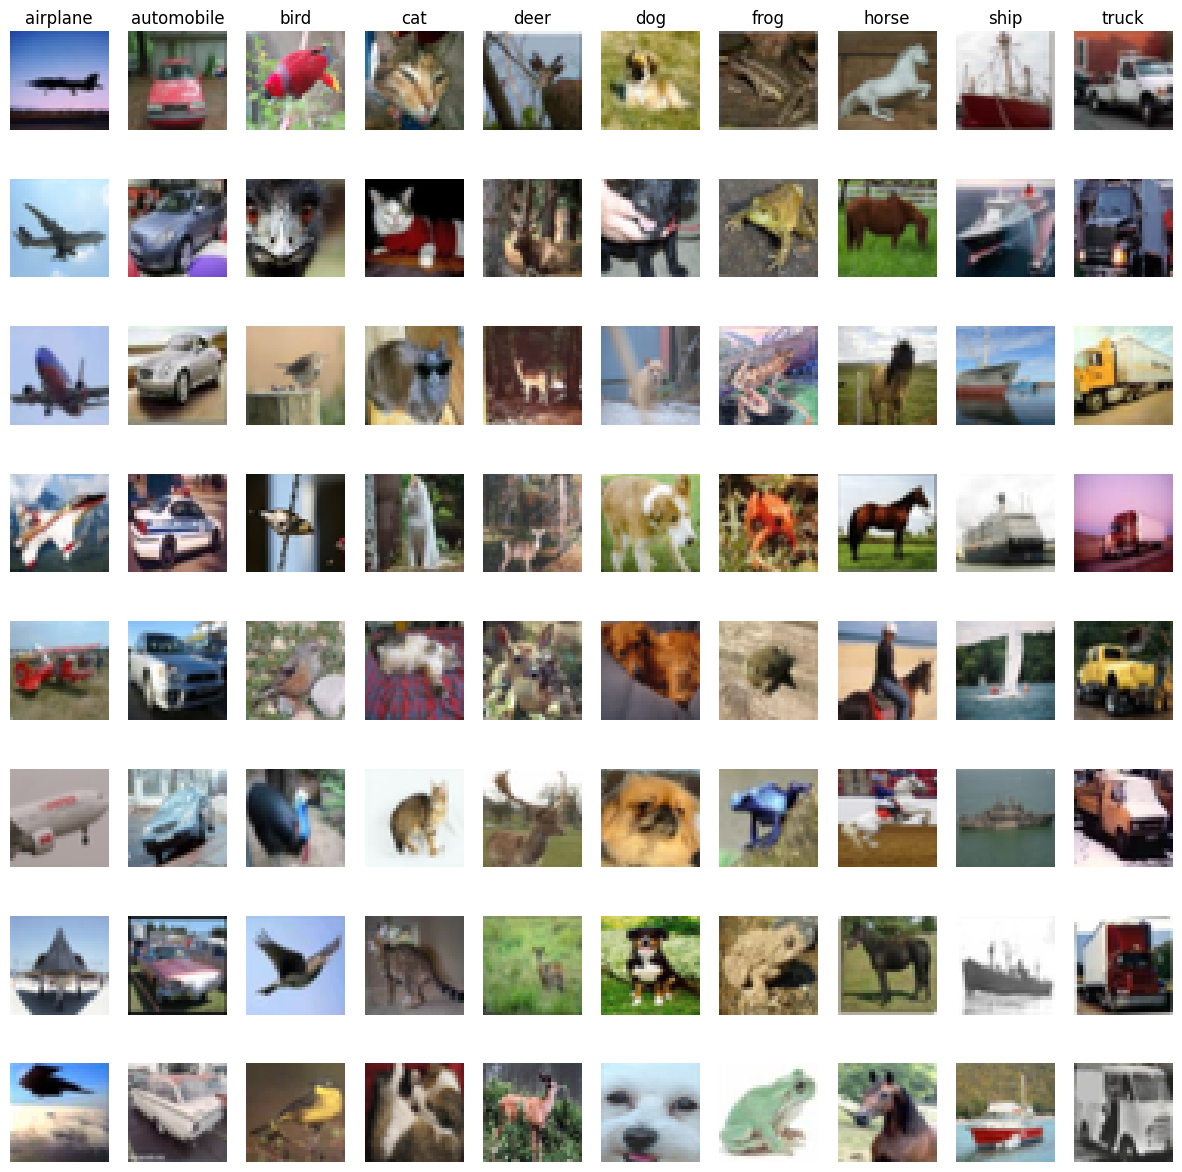

In [ ]:
def plot_cifar10_grid():
    classes = test_loader.dataset.classes
    total_samples = 8
    plt.figure(figsize=(15,15))
    for label, sample in enumerate(classes):
        class_idxs = np.flatnonzero(label == np.array(test_loader.dataset.targets))
        sample_idxs = np.random.choice(class_idxs, total_samples, replace = False)
        for i, idx in enumerate(sample_idxs):
            plt_idx = i*len(classes) + label + 1
            plt.subplot(total_samples, len(classes), plt_idx)
            plt.imshow(test_loader.dataset.data[idx])
            plt.axis('off')
            
            if i == 0: plt.title(sample)
    plt.show()

plot_cifar10_grid() 

### Calcular accuracy y loss


In [ ]:
def evaluate(model, loader):
    num_correct = 0
    num_total = 0
    total_loss = 0.0
    model.eval()
    model = model.to(device=device)
    with torch.no_grad():
        for xi, yi in loader:
            xi = xi.to(device=device, dtype=torch.float32)
            yi = yi.to(device=device, dtype=torch.long)
            scores = model(xi)
            loss = F.cross_entropy(scores, yi)
            _, pred = scores.max(dim=1)
            num_correct += (pred == yi).sum().item()
            num_total += yi.size(0)
            total_loss += loss.item() * yi.size(0)
    acc = num_correct / num_total
    avg_loss = total_loss / num_total
    return acc, avg_loss

### Loop de entrenamiento

In [ ]:
def train(model, optimiser, epochs=100):
    model = model.to(device=device)
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    for epoch in range(epochs):
        model = model.to(device=device)
        for i, (xi, yi) in enumerate(train_loader):
            model.train()
            xi = xi.to(device=device, dtype=torch.float32)
            yi = yi.to(device=device, dtype=torch.long)
            scores = model(xi)
            cost = F.cross_entropy(input=scores, target=yi)

            optimiser.zero_grad()
            cost.backward()
            optimiser.step()

        train_acc, train_loss = evaluate(model, train_loader)
        val_acc, val_loss = evaluate(model, val_loader)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(
            f"Epoch: {epoch+1}/{epochs} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"val_loss: {val_loss:.4f} | "
            f"val_acc: {val_acc:.4f}"
        )

    return history

### Sequential linear

In [ ]:
hidden1 = 256 
hidden = 256
lr = 0.001
epochs = 10
model1 = nn.Sequential(nn.Flatten(),
                       nn.Linear(in_features=32*32*3, out_features=hidden1), nn.ReLU(),
                       nn.Linear(in_features=hidden1, out_features=hidden), nn.ReLU(),
                       nn.Linear(in_features=hidden, out_features=10))
optimiser = torch.optim.Adam(model1.parameters(), lr=lr)

Epoch: 1/10 | train_loss: 1.4624 | train_acc: 0.4804 | val_loss: 1.4944 | val_acc: 0.4792
Epoch: 2/10 | train_loss: 1.3767 | train_acc: 0.5122 | val_loss: 1.4714 | val_acc: 0.4774
Epoch: 3/10 | train_loss: 1.2503 | train_acc: 0.5583 | val_loss: 1.3984 | val_acc: 0.5110
Epoch: 4/10 | train_loss: 1.1851 | train_acc: 0.5820 | val_loss: 1.4079 | val_acc: 0.5190
Epoch: 5/10 | train_loss: 1.0912 | train_acc: 0.6120 | val_loss: 1.3914 | val_acc: 0.5258
Epoch: 6/10 | train_loss: 1.0224 | train_acc: 0.6374 | val_loss: 1.3851 | val_acc: 0.5262
Epoch: 7/10 | train_loss: 0.9701 | train_acc: 0.6532 | val_loss: 1.4210 | val_acc: 0.5238
Epoch: 8/10 | train_loss: 0.9061 | train_acc: 0.6773 | val_loss: 1.4333 | val_acc: 0.5354
Epoch: 9/10 | train_loss: 0.8964 | train_acc: 0.6869 | val_loss: 1.5197 | val_acc: 0.5280
Epoch: 10/10 | train_loss: 0.8045 | train_acc: 0.7121 | val_loss: 1.4935 | val_acc: 0.5256


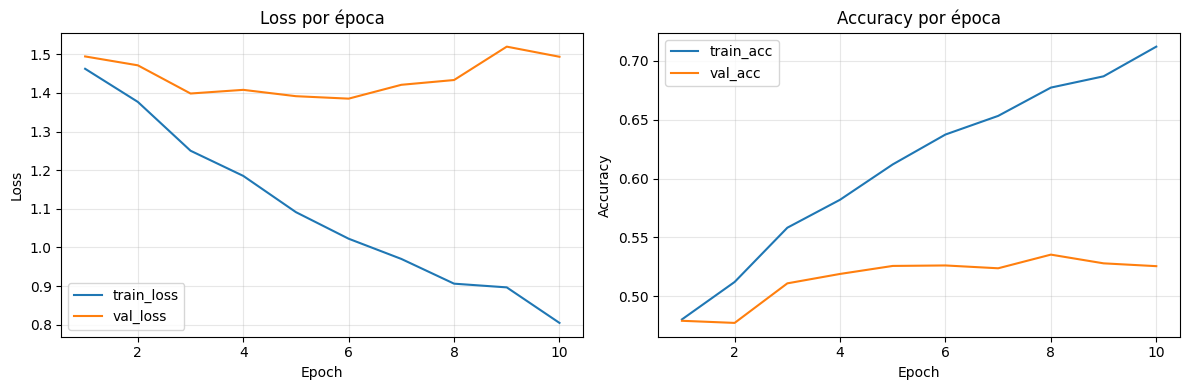

CPU times: total: 3min 7s
Wall time: 8min 38s


In [ ]:
%%time
history = train(model1, optimiser, epochs)
plot_history(history)

### Sequential CNN

In [ ]:
channel1 = 16
channel2 = 32
epochs = 10
lr = 0.001
modelCNN1 = nn.Sequential(nn.Conv2d(in_channels=3, out_channels=channel1, 
                                   kernel_size=3, padding=1),
                          nn.ReLU(),
                          nn.Conv2d(in_channels=channel1, out_channels=channel2,
                                    kernel_size= 3, padding=1),
                          nn.ReLU(),
                          nn.MaxPool2d(2, 2),
                          nn.Flatten(),
                          nn.Linear(in_features=16*16*channel2, out_features=10)                        
                )
optimiser = torch.optim.Adam(modelCNN1.parameters(), lr)

In [ ]:
%%time
history = train(modelCNN1, optimiser, epochs)

Epoch: 1/10 | train_loss: 1.0274 | train_acc: 0.6463 | val_loss: 1.0958 | val_acc: 0.6202
Epoch: 2/10 | train_loss: 0.8170 | train_acc: 0.7254 | val_loss: 0.9656 | val_acc: 0.6608
Epoch: 3/10 | train_loss: 0.7377 | train_acc: 0.7494 | val_loss: 0.9590 | val_acc: 0.6668
Epoch: 4/10 | train_loss: 0.6542 | train_acc: 0.7795 | val_loss: 0.9570 | val_acc: 0.6756
Epoch: 5/10 | train_loss: 0.5732 | train_acc: 0.8075 | val_loss: 0.9659 | val_acc: 0.6744
Epoch: 6/10 | train_loss: 0.5131 | train_acc: 0.8291 | val_loss: 0.9816 | val_acc: 0.6744
CPU times: total: 2min 6s
Wall time: 6min 19s


KeyboardInterrupt: 

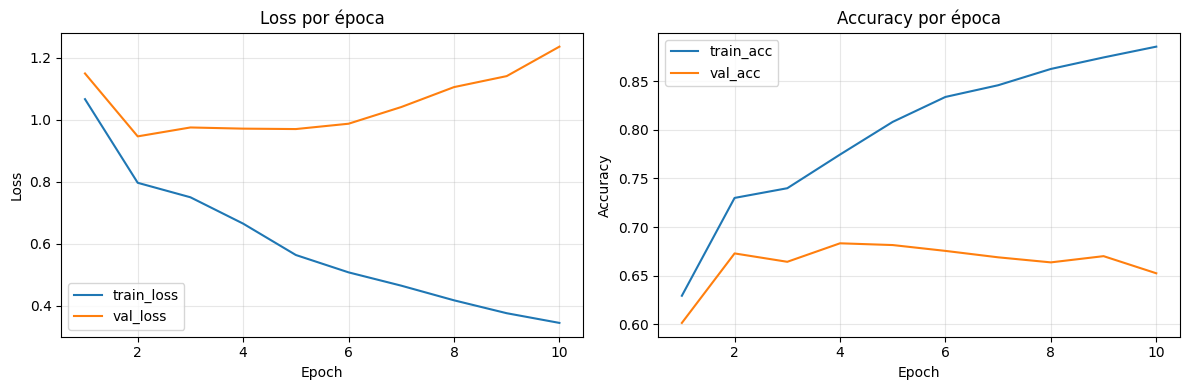

In [ ]:
plot_history(history)

### OOP (Programación orientada a objetos)

In [ ]:
class CNN_class1(nn.Module):
    def __init__(self, in_channel, channel1, channel2):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels = in_channel, out_channels = channel1,
                              kernel_size=3, padding = 1)
        self.conv2 = nn.Conv2d(in_channels = channel1, out_channels = channel2,
                              kernel_size=3, padding=1)
        self.max_pool = nn.MaxPool2d(2,2)
        self.fc = nn.Linear(in_features=16*16*channel2, out_features=10)
        self.flatten = nn.Flatten()
    def forward(self, x):
        x = F.relu(self.conv2(F.relu(self.conv1(x))))
        x = self.max_pool(x)
        x = self.flatten(x)
        return self.fc(x)

In [ ]:
channel1 = 16
channel2 = 32
epochs = 10
lr = 0.001
modelCNN2 = CNN_class1(3, channel1, channel2)
optimiser = torch.optim.Adam(modelCNN2.parameters(), lr)

In [ ]:
%%time
history = train(modelCNN2, optimiser, epochs)

Epoch: 1/10 | train_loss: 0.9949 | train_acc: 0.6590 | val_loss: 1.0555 | val_acc: 0.6334
Epoch: 2/10 | train_loss: 0.8238 | train_acc: 0.7208 | val_loss: 0.9609 | val_acc: 0.6730
Epoch: 3/10 | train_loss: 0.7251 | train_acc: 0.7548 | val_loss: 0.9411 | val_acc: 0.6756
Epoch: 4/10 | train_loss: 0.6539 | train_acc: 0.7793 | val_loss: 0.9443 | val_acc: 0.6770
Epoch: 5/10 | train_loss: 0.5981 | train_acc: 0.7996 | val_loss: 0.9798 | val_acc: 0.6750
Epoch: 6/10 | train_loss: 0.5204 | train_acc: 0.8296 | val_loss: 1.0001 | val_acc: 0.6716
Epoch: 7/10 | train_loss: 0.4609 | train_acc: 0.8500 | val_loss: 1.0286 | val_acc: 0.6718
Epoch: 8/10 | train_loss: 0.4395 | train_acc: 0.8543 | val_loss: 1.0854 | val_acc: 0.6600
Epoch: 9/10 | train_loss: 0.3923 | train_acc: 0.8700 | val_loss: 1.1662 | val_acc: 0.6590
Epoch: 10/10 | train_loss: 0.3437 | train_acc: 0.8906 | val_loss: 1.1933 | val_acc: 0.6652


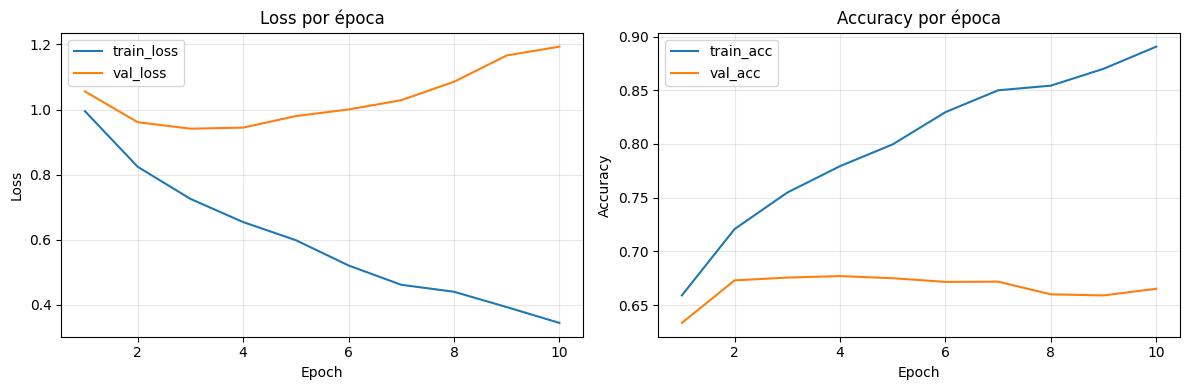

In [ ]:
plot_history(history)

### Otra forma

In [ ]:
conv_k_3 = lambda channel1, channel2: nn.Conv2d(channel1, channel2, kernel_size=3, padding=1)

In [ ]:
class CNN_class2(nn.Module):
    def __init__(self, in_channel, channel1, channel2):
        super().__init__()
        self.conv1 = conv_k_3(in_channel, channel1)
        nn.init.kaiming_uniform_(self.conv1.weight)

        self.conv2 = conv_k_3(channel1, channel2)
        self.max_pool = nn.MaxPool2d(2,2)
        self.fc = nn.Linear(in_features=16*16*channel2, out_features=10)
        self.flatten = nn.Flatten()
    def forward(self, x):
        x = F.relu(self.conv2(F.relu(self.conv1(x))))
        x = self.max_pool(x)
        x = self.flatten(x)
        return self.fc(x)
    

In [ ]:
channel1 = 16
channel2 = 32
epochs = 10
lr = 0.001
modelCNN3 = CNN_class2(3, channel1, channel2)
optimiser = torch.optim.Adam(modelCNN3.parameters(), lr)

In [ ]:
%%time
history = train(modelCNN3, optimiser, epochs)

Epoch: 1/10 | train_loss: 0.9864 | train_acc: 0.6584 | val_loss: 1.0902 | val_acc: 0.6130
Epoch: 2/10 | train_loss: 0.7898 | train_acc: 0.7348 | val_loss: 0.9762 | val_acc: 0.6668
Epoch: 3/10 | train_loss: 0.7220 | train_acc: 0.7500 | val_loss: 1.0152 | val_acc: 0.6604
Epoch: 4/10 | train_loss: 0.5882 | train_acc: 0.8054 | val_loss: 0.9598 | val_acc: 0.6768
Epoch: 5/10 | train_loss: 0.5307 | train_acc: 0.8252 | val_loss: 1.0019 | val_acc: 0.6714
Epoch: 6/10 | train_loss: 0.4544 | train_acc: 0.8505 | val_loss: 1.0293 | val_acc: 0.6828
Epoch: 7/10 | train_loss: 0.4010 | train_acc: 0.8713 | val_loss: 1.0899 | val_acc: 0.6716
Epoch: 8/10 | train_loss: 0.3571 | train_acc: 0.8856 | val_loss: 1.1631 | val_acc: 0.6598
Epoch: 9/10 | train_loss: 0.3165 | train_acc: 0.9005 | val_loss: 1.2296 | val_acc: 0.6602
Epoch: 10/10 | train_loss: 0.2850 | train_acc: 0.9083 | val_loss: 1.3052 | val_acc: 0.6548


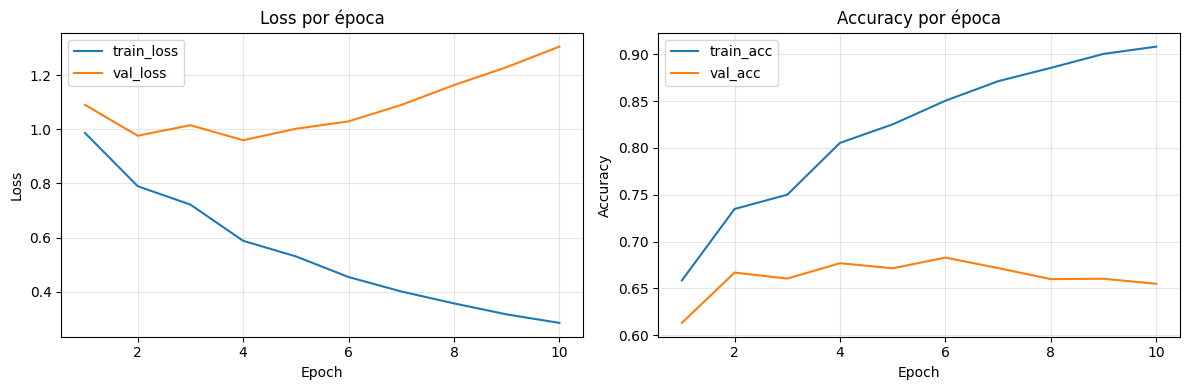

In [ ]:
plot_history(history)

In [ ]:
class CNN_class3(nn.Module):
    def __init__(self, in_channel, channel1, channel2):
        super().__init__()
        self.conv1 = conv_k_3(in_channel, channel1)
        self.bn1 = nn.BatchNorm2d(channel1)

        self.conv2 = conv_k_3(channel1, channel2)
        self.bn2 = nn.BatchNorm2d(channel2)
        
        self.max_pool = nn.MaxPool2d(2,2)

    def forward(self, x):
        x = F.relu(self.bn2(self.conv2(F.relu(self.bn1(self.conv1(x))))))
        return self.max_pool(x)

In [ ]:
channel1 = 16
channel2 = 32
channel3 = 64
channel4 = 128
epochs = 10
lr = 0.001
modelCNN4 = nn.Sequential(CNN_class3(3,channel1, channel2),
                          CNN_class3(channel2, channel4, channel4),
                          nn.Flatten(),

                          # Nueva Capa Densa Intermedia
                          nn.Linear(in_features=8*8*channel4, out_features=128), # Capa oculta
                          nn.ReLU(),                                             # Activación
                          nn.Dropout(p=0.4),                                     # Regularización para evitar overfitting
    
                          # Capa de Clasificación Final
                          nn.Linear(in_features=128, out_features=10)
        )
optimiser = torch.optim.Adam(modelCNN4.parameters(), lr)

Epoch: 1/10 | train_loss: 1.1768 | train_acc: 0.5849 | val_loss: 1.1908 | val_acc: 0.5792
Epoch: 2/10 | train_loss: 0.8928 | train_acc: 0.6752 | val_loss: 0.9397 | val_acc: 0.6680
Epoch: 3/10 | train_loss: 0.8151 | train_acc: 0.7045 | val_loss: 0.8832 | val_acc: 0.6848
Epoch: 4/10 | train_loss: 0.7158 | train_acc: 0.7473 | val_loss: 0.8007 | val_acc: 0.7298
Epoch: 5/10 | train_loss: 0.7713 | train_acc: 0.7301 | val_loss: 0.8619 | val_acc: 0.7016
Epoch: 6/10 | train_loss: 0.6158 | train_acc: 0.7782 | val_loss: 0.7459 | val_acc: 0.7370
Epoch: 7/10 | train_loss: 0.5762 | train_acc: 0.7974 | val_loss: 0.7259 | val_acc: 0.7492
Epoch: 8/10 | train_loss: 0.5057 | train_acc: 0.8261 | val_loss: 0.6831 | val_acc: 0.7734
Epoch: 9/10 | train_loss: 0.4930 | train_acc: 0.8319 | val_loss: 0.6961 | val_acc: 0.7678
Epoch: 10/10 | train_loss: 0.4077 | train_acc: 0.8598 | val_loss: 0.6361 | val_acc: 0.7872


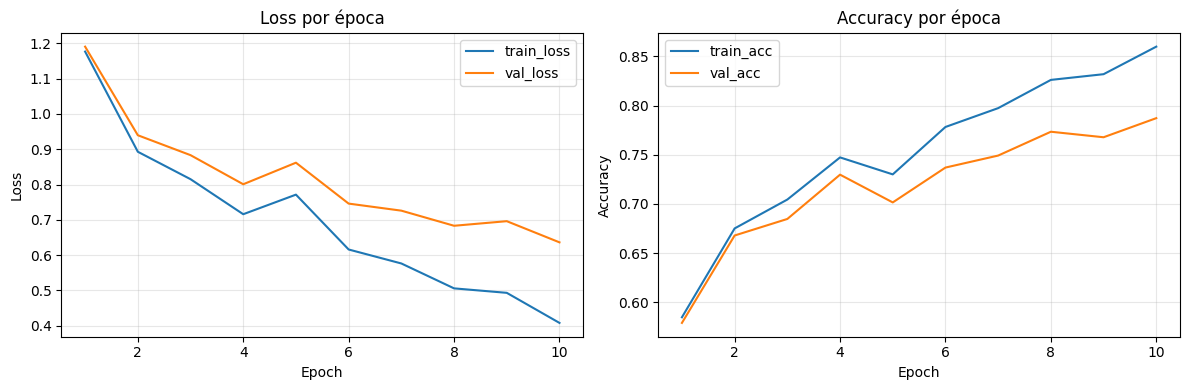

In [ ]:
%%time
history = train(modelCNN5, optimiser, epochs)
plot_history(history)

In [ ]:
test_acc, _ = evaluate(modelCNN4, test_loader)
print(f'test_acc: {test_acc:.4f}')

test_acc: 0.7860
